In [272]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

## 1. Data Loading and Merging

In [273]:
factsales = pd.read_csv('Tables/factsales.csv')
factsales.head()

,SalesID,OrderID,ProductID,CustomerID,DateID,GeographyID,Sales,Quantity,Discount,Profit,Market,ShipMode,Discount Category
0,1200,CA-2011-169642,OFF-ST-10002574,BB-10990,447,27,276.28,2,0.0,0.0,US,Second Class,Non-Discounted
1,1486,CA-2012-142993,OFF-ST-10000934,KA-16525,555,48,81.96,2,0.0,0.0,US,Standard Class,Non-Discounted
2,1501,CA-2012-130736,OFF-FA-10003467,JF-15490,705,48,3.96,2,0.0,0.0,US,First Class,Non-Discounted
3,2167,CA-2011-136567,OFF-ST-10004337,PS-19045,17,105,122.48,2,0.0,0.0,US,First Class,Non-Discounted
4,5202,AG-2011-4560,FUR-DEF-10000572,EG-3900,17,805,103.92,2,0.0,0.0,Africa,Standard Class,Non-Discounted


In [274]:
dimproduct = pd.read_csv('Tables/dimproduct.csv')
dimproduct.head()

,ProductID,ProductName,Category,SubCategory
0,OFF-EAT-10000522,"Eaton Computer Printout Paper, Multicolor",Office Supplies,Paper
1,OFF-EAT-10000652,"Eaton Computer Printout Paper, 8.5 x 11",Office Supplies,Paper
2,OFF-EAT-10000820,"Eaton Message Books, Multicolor",Office Supplies,Paper
3,OFF-EAT-10000854,"Eaton Parchment Paper, Recycled",Office Supplies,Paper
4,OFF-EAT-10001025,"Eaton Note Cards, Multicolor",Office Supplies,Paper


In [275]:
dimgeography = pd.read_csv('Tables/dimgeograohy.csv')
dimgeography.head()

,GeographyID,City,State,Country,Region
0,78,Paris,Ile-de-France,United States,Central
1,84,Boulogne-Billancourt,Ile-de-France,United States,Central
2,85,Malakoff,Ile-de-France,United States,Central
3,103,Chelles,Ile-de-France,United States,Central
4,142,Argenteuil,Ile-de-France,United States,Central


In [276]:
dimorder = pd.read_csv('Tables/order.csv')
dimorder.rename(columns=lambda x: x.replace(" ", ""), inplace=True)
dimorder.head()

,OrderID,CustomerID,OrderPriority,OrderDate,Market
0,ID-2011-11126,AP-10720,Medium,2011-11-25 00:00:00.000,APAC
1,ID-2011-11385,TH-21100,Medium,2011-08-05 00:00:00.000,APAC
2,ID-2011-12596,CM-12235,Medium,2011-01-03 00:00:00.000,APAC
3,ID-2011-13114,DB-13060,Medium,2011-12-14 00:00:00.000,APAC
4,ID-2011-13170,AG-10525,Medium,2011-12-15 00:00:00.000,APAC


In [277]:
dimship = pd.read_csv('Tables/shipping.csv')
dimship.rename(columns=lambda x: x.replace(" ", ""), inplace=True)
dimship.head()

,ShippingID,OrderID,ShipDate,ShipMode,City,State,Country,Region
0,21150,CA-2012-149846,2012-05-26 00:00:00.000,Standard Class,Los Angeles,California,United States,West
1,21257,CA-2014-133865,2014-05-13 00:00:00.000,Standard Class,Los Angeles,California,United States,West
2,21374,CA-2013-107104,2013-12-01 00:00:00.000,Standard Class,Los Angeles,California,United States,West
3,21586,US-2013-126452,2013-08-29 00:00:00.000,Standard Class,Los Angeles,California,United States,West
4,22031,CA-2012-135580,2013-01-03 00:00:00.000,Standard Class,Los Angeles,California,United States,West


In [278]:
# Merge the fact and dimension tables on common keys
df_merged = factsales.merge(dimproduct, on='ProductID', how='left') \
                     .merge(dimgeography, on='GeographyID', how='left')

df_merged.head()

,SalesID,OrderID,ProductID,CustomerID,DateID,GeographyID,Sales,Quantity,Discount,Profit,Market,ShipMode,Discount Category,ProductName,Category,SubCategory,City,State,Country,Region
0,1200,CA-2011-169642,OFF-ST-10002574,BB-10990,447,27,276.28,2,0.0,0.0,US,Second Class,Non-Discounted,"SAFCO Commercial Wire Shelving, Black",Office Supplies,Storage,Los Angeles,California,United States,West
1,1486,CA-2012-142993,OFF-ST-10000934,KA-16525,555,48,81.96,2,0.0,0.0,US,Standard Class,Non-Discounted,"Contico 72""H Heavy-Duty Storage System",Office Supplies,Storage,Seattle,Washington,United States,West
2,1501,CA-2012-130736,OFF-FA-10003467,JF-15490,705,48,3.96,2,0.0,0.0,US,First Class,Non-Discounted,"Alliance Big Bands Rubber Bands, 12/Pack",Office Supplies,Fasteners,Seattle,Washington,United States,West
3,2167,CA-2011-136567,OFF-ST-10004337,PS-19045,17,105,122.48,2,0.0,0.0,US,First Class,Non-Discounted,"SAFCO Commercial Wire Shelving, 72h",Office Supplies,Storage,Harrisonburg,Virginia,United States,South
4,5202,AG-2011-4560,FUR-DEF-10000572,EG-3900,17,805,103.92,2,0.0,0.0,Africa,Standard Class,Non-Discounted,"Deflect-O Photo Frame, Duo Pack",Furniture,Furnishings,Annaba,Annaba,United States,Africa


## 2. Data Cleaning and Outlier Removal

In [279]:
# Check for missing values
df_merged.isna().sum()

SalesID              0
OrderID              0
ProductID            0
CustomerID           0
DateID               0
GeographyID          0
Sales                0
Quantity             0
Discount             0
Profit               0
Market               0
ShipMode             0
Discount Category    0
ProductName          0
Category             0
SubCategory          0
City                 0
State                0
Country              0
Region               0
dtype: int64

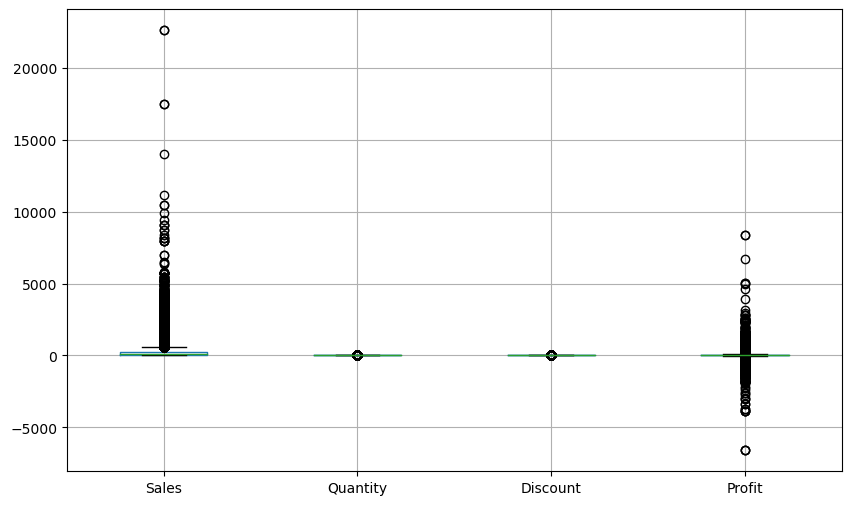

In [280]:
# Plot boxplots for numeric columns to visualize potential outliers
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df_merged[numeric_cols].boxplot(figsize=(10, 6))
plt.show()


In [281]:
# Remove outliers using the IQR method for each numeric column
for col in numeric_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_merged = df_merged[(df_merged[col] >= lower_bound) & (df_merged[col] <= upper_bound)]


## 3. Correlation Analysis

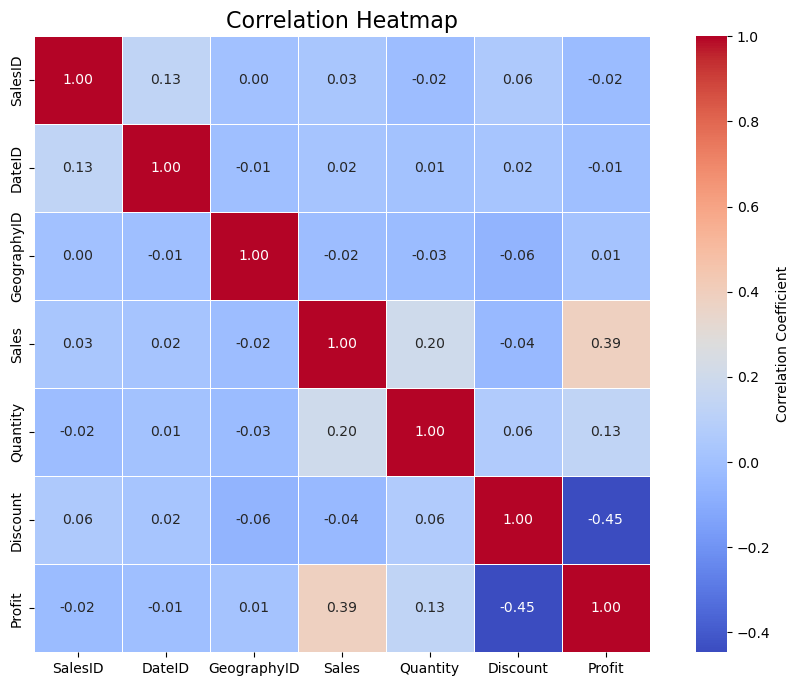

In [282]:
# Compute correlation matrix for numeric columns
corr = df_merged.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'}, square=True)  
plt.title('Correlation Heatmap', fontsize=16)
plt.show()


### Key Observations
Profit has its strongest linear relationship (among the features shown) with Discount (negative) and Sales (positive).

Quantity shows relatively low correlation with Profit and Sales.

Discount doesn’t seem to strongly correlate with Sales or Quantity, but it does impact Profit moderately.

# Q1

## 4. Preparing Data for Regression

In [57]:
X = df_merged[['Sales', 'Quantity', 'Discount']] 
y = df_merged['Profit']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)


In [59]:
# Standardize the feature data for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Basic Linear Regression Model

In [60]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nBasic Linear Regression Results:")
print("Linear Regression MSE:", mse)
print("Linear Regression R2:", r2)



Basic Linear Regression Results:
Linear Regression MSE: 215.3574457495804
Linear Regression R2: 0.35696965060479857


### Analysis:
 The initial linear model achieves an MSE of about 215.36 and R² of 0.357, indicating that roughly 35.7% of the variance in Profit is explained by the model. This suggests there is room for improvement.

## 6. Define Evaluation Function for Models


In [61]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    print(f"{model_name} - R^2 Train: {r2_train:.4f}, R^2 Test: {r2_test:.4f}")
    print(f"{model_name} - MSE Train: {mse_train:.4f}, MSE Test: {mse_test:.4f}\n")
    
    return r2_train, r2_test


## 7. Polynomial Regression and Regularization Experiments


In [62]:
# We try polynomial features of various degrees (from 1 to 7) to see if a higher degree
# improves the model performance and to check for potential overfitting.
degrees_to_try = [1, 2, 3, 4,5, 6, 7]

for deg in degrees_to_try:
    print(f"----- Degree {deg} -----")
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    # Linear Regression
    print("Linear Regression:")
    lr = LinearRegression()
    evaluate_model(lr, X_train_poly, y_train, X_test_poly, y_test, model_name=f"Linear Regression (Degree {deg})")
    
    # Ridge Regression (L2 Regularization)
    print("Ridge Regression:")
    ridge = Ridge(alpha=1.0)  
    evaluate_model(ridge, X_train_poly, y_train, X_test_poly, y_test, model_name=f"Ridge Regression (Degree {deg})")
    
    # Lasso Regression (L1 Regularization)
    print("Lasso Regression:")
    lasso = Lasso(alpha=0.1, max_iter=10000)
    evaluate_model(lasso, X_train_poly, y_train, X_test_poly, y_test, model_name=f"Lasso Regression (Degree {deg})")
    
    print("\n")



----- Degree 1 -----
Linear Regression:
Linear Regression (Degree 1) - R^2 Train: 0.3428, R^2 Test: 0.3570
Linear Regression (Degree 1) - MSE Train: 220.2465, MSE Test: 215.3574

Ridge Regression:
Ridge Regression (Degree 1) - R^2 Train: 0.3428, R^2 Test: 0.3570
Ridge Regression (Degree 1) - MSE Train: 220.2465, MSE Test: 215.3576

Lasso Regression:
Lasso Regression (Degree 1) - R^2 Train: 0.3428, R^2 Test: 0.3566
Lasso Regression (Degree 1) - MSE Train: 220.2735, MSE Test: 215.4761



----- Degree 2 -----
Linear Regression:
Linear Regression (Degree 2) - R^2 Train: 0.4160, R^2 Test: 0.4182
Linear Regression (Degree 2) - MSE Train: 195.7270, MSE Test: 194.8570

Ridge Regression:
Ridge Regression (Degree 2) - R^2 Train: 0.4160, R^2 Test: 0.4182
Ridge Regression (Degree 2) - MSE Train: 195.7270, MSE Test: 194.8566

Lasso Regression:
Lasso Regression (Degree 2) - R^2 Train: 0.4157, R^2 Test: 0.4186
Lasso Regression (Degree 2) - MSE Train: 195.8345, MSE Test: 194.7318



----- Degree 3 ---

c:\Users\2021\anaconda3\envs\quera\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.132e+06, tolerance: 1.033e+03
  model = cd_fast.enet_coordinate_descent(


Lasso Regression (Degree 6) - R^2 Train: 0.4687, R^2 Test: 0.4717
Lasso Regression (Degree 6) - MSE Train: 178.0674, MSE Test: 176.9370



----- Degree 7 -----
Linear Regression:
Linear Regression (Degree 7) - R^2 Train: 0.4849, R^2 Test: 0.4773
Linear Regression (Degree 7) - MSE Train: 172.6449, MSE Test: 175.0684

Ridge Regression:
Ridge Regression (Degree 7) - R^2 Train: 0.4841, R^2 Test: 0.4776
Ridge Regression (Degree 7) - MSE Train: 172.9179, MSE Test: 174.9519

Lasso Regression:
Lasso Regression (Degree 7) - R^2 Train: 0.4717, R^2 Test: 0.4723
Lasso Regression (Degree 7) - MSE Train: 177.0521, MSE Test: 176.7351





c:\Users\2021\anaconda3\envs\quera\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.755e+06, tolerance: 1.033e+03
  model = cd_fast.enet_coordinate_descent(


### Analysis:
 - As the degree increases, the training R² generally increases.
 - For degree 1 to 5, test R² improves, but beyond that (degrees 6 and 7), the gain is minimal or even a slight drop in test performance.
 - This indicates that degree 5 might be a good trade-off between model complexity and generalization.
 - Regularized models (Ridge and Lasso) behave similarly to Linear Regression in these experiments.


## 8. Tree-Based Models


In [63]:
print("----- Tree-Based Models -----")
print("Random Forest:")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
evaluate_model(rf, X_train_scaled, y_train, X_test_scaled, y_test, model_name="Random Forest")

print("XGBoost:")
xgb_model = XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
evaluate_model(xgb_model, X_train_scaled, y_train, X_test_scaled, y_test, model_name="XGBoost")


----- Tree-Based Models -----
Random Forest:
Random Forest - R^2 Train: 0.8949, R^2 Test: 0.5802
Random Forest - MSE Train: 35.2311, MSE Test: 140.5813

XGBoost:
XGBoost - R^2 Train: 0.5855, R^2 Test: 0.4988
XGBoost - MSE Train: 138.9072, MSE Test: 167.8656



(0.5855416007844849, 0.49877443532179067)

### Analysis:
 - Random Forest shows a very high R² on training (≈0.895) but lower on test (≈0.580), indicating some overfitting.
 - XGBoost has slightly lower performance compared to Random Forest on test data.


## 9. Hyperparameter Tuning using Pipeline and GridSearchCV


In [64]:
# Pipeline for Polynomial Features followed by Ridge Regression
pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

# Define parameter grid for polynomial degree and ridge regularization parameter alpha
param_grid = {
    'poly__degree': [3, 4, 5, 6], 
    'ridge__alpha': [0.1, 1, 10, 100] 
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

print("Best parameters for Polynomial Ridge Regression:")
print("Best parameter combination:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best parameters for Polynomial Ridge Regression:
Best parameter combination: {'poly__degree': 6, 'ridge__alpha': 1}
Best CV R²: 0.4732413651082926


### Analysis:
- The best combination found is a polynomial degree of 6 and a ridge alpha of 1.
- This model achieved a CV R² of approximately 0.473, which is an improvement over the basic linear model.


## 10. Hyperparameter Tuning for Random Forest


In [65]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), 
                         param_grid_rf, cv=5, scoring='r2')
grid_rf.fit(X_train_scaled, y_train)

print("Best parameters for Random Forest:")
print("Best parameters:", grid_rf.best_params_)
print("Best CV R² for Random Forest:", grid_rf.best_score_)

Best parameters for Random Forest:
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² for Random Forest: 0.545470062084105


### Analysis:
- The best parameters for Random Forest are: n_estimators=200, min_samples_split=5, and max_depth=None.
- The best CV R² for Random Forest is about 0.545, which is higher than the Polynomial Ridge model.


## 11. Final Model Training and Evaluation for Random Forest


In [66]:
# Use the best Random Forest estimator from GridSearchCV
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train_scaled, y_train)

y_pred_rf = best_rf.predict(X_test_scaled)

final_r2_rf = r2_score(y_test, y_pred_rf)
final_mse_rf = mean_squared_error(y_test, y_pred_rf)

print("\nFinal Random Forest model performance on test data:")
print("R²:", final_r2_rf)
print("MSE:", final_mse_rf)



Final Random Forest model performance on test data:
R²: 0.5848034615686885
MSE: 139.05357046480646


### Final Analysis:
- The final Random Forest model achieved an R² of approximately 0.585 and an MSE of about 139.05 on the test data.
- This indicates that the model explains around 58.5% of the variance in Profit, which is a significant improvement over the basic linear model.


# Q2

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix


In [126]:
# Select numerical features for clustering
features = ['Sales', 'Quantity', 'Discount', 'Profit']
X = df_merged[features].dropna()

In [127]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

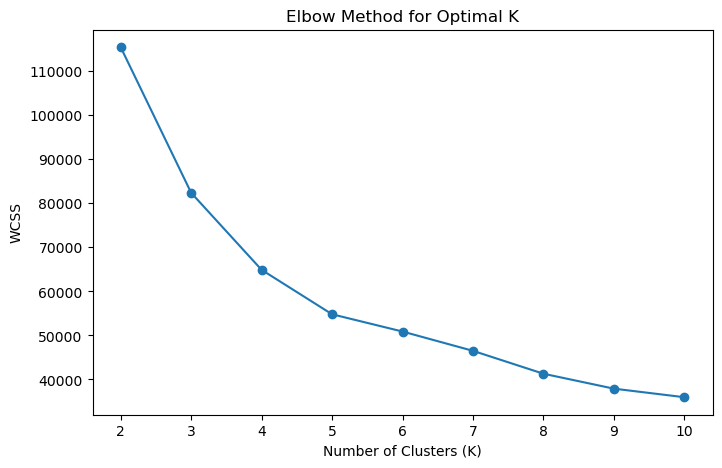

In [128]:
# Elbow Method to determine optimal K
wcss = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

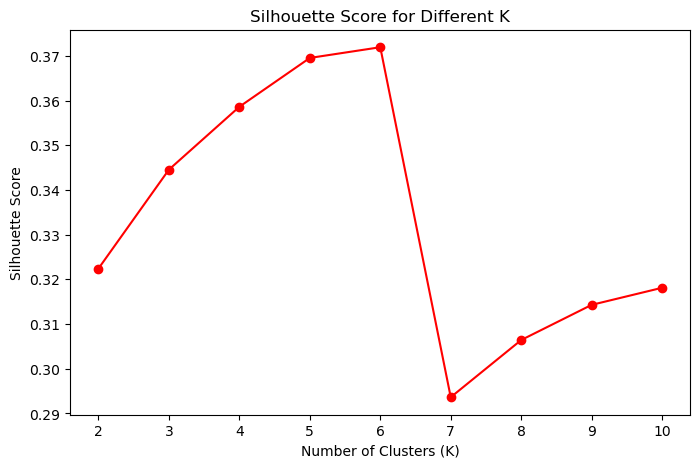

In [129]:
# Silhouette Score for different K values
sil_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, cluster_labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o', color='red')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')
plt.show()

In [130]:
# Apply KMeans clustering with K=5
kmeans = KMeans(n_clusters=5, random_state=42)
df_merged['Cluster'] = kmeans.fit_predict(X_scaled)

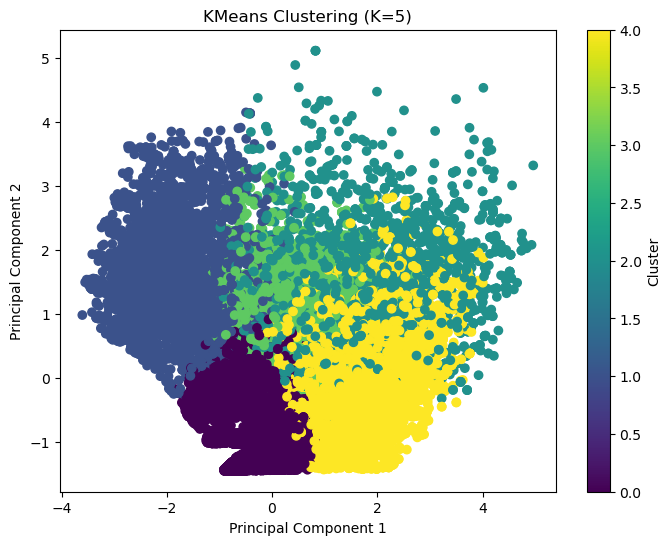

Cluster centers (in original feature space):
[[-0.45995295 -0.61213002 -0.33592998 -0.2502122 ]
 [-0.27108131  0.03886581  2.22815448 -1.26696212]
 [ 2.78912807  0.31593592  0.02425817  0.41520889]
 [-0.19674425  1.33039148 -0.27740804  0.00292086]
 [ 0.65485204  0.09156077 -0.42132207  1.66489624]]


In [132]:
# Visualize the clusters (for 2D visualization, we'll use the first two principal components)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_merged['Cluster'], cmap='viridis')
plt.title('KMeans Clustering (K=5)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

# Show cluster centers in original feature space (before PCA)
cluster_centers = kmeans.cluster_centers_
print("Cluster centers (in original feature space):")
print(cluster_centers)

In [284]:
merged = df_merged.merge(dimship, on='OrderID', how='left') \
                     .merge(dimorder, on='OrderID', how='left')

merged.head()

,SalesID,OrderID,ProductID,CustomerID_x,DateID,GeographyID,Sales,Quantity,Discount,Profit,...,ShipDate,ShipMode_y,City_y,State_y,Country_y,Region_y,CustomerID_y,OrderPriority,OrderDate,Market_y
0,1200,CA-2011-169642,OFF-ST-10002574,BB-10990,447,27,276.28,2,0.0,0.0,...,2011-07-30 00:00:00.000,Second Class,Los Angeles,California,United States,West,BB-10990,Medium,2011-07-27 00:00:00.000,US
1,1486,CA-2012-142993,OFF-ST-10000934,KA-16525,555,48,81.96,2,0.0,0.0,...,2012-10-17 00:00:00.000,Standard Class,Seattle,Washington,United States,West,KA-16525,Medium,2012-10-12 00:00:00.000,US
2,1501,CA-2012-130736,OFF-FA-10003467,JF-15490,705,48,3.96,2,0.0,0.0,...,2012-12-09 00:00:00.000,First Class,Seattle,Washington,United States,West,JF-15490,Critical,2012-12-07 00:00:00.000,US
3,2167,CA-2011-136567,OFF-ST-10004337,PS-19045,17,105,122.48,2,0.0,0.0,...,2011-12-21 00:00:00.000,First Class,Harrisonburg,Virginia,United States,South,PS-19045,High,2011-12-20 00:00:00.000,US
4,5202,AG-2011-4560,FUR-DEF-10000572,EG-3900,17,805,103.92,2,0.0,0.0,...,2011-12-27 00:00:00.000,Standard Class,Annaba,Annaba,Algeria,Africa,EG-3900,Low,2011-12-20 00:00:00.000,Africa


In [285]:
# Remove columns using the 'columns' parameter
merged = merged.drop(columns=['ShipMode_y', 'City_y', 'State_y', 'Country_y', 'Region_y', 'CustomerID_y', 'Market_y'])
merged.rename(columns={
    'Market_x': 'Market',
    'ShipMode_x': 'ShipMode',
    'City_x':'City',
    'State_x':'State',
    'Country_x' : 'Country',
    'Region_x' : 'Region'
    
}, inplace=True)


In [286]:
# Label Encoding for categorical variables
label_encoders = {}
categorical_cols = ['Category', 'SubCategory', 'Market', 'Discount Category', 'City', 'State', 'Country', 'Region']
for col in categorical_cols:
    le = LabelEncoder()
    merged[col] = le.fit_transform(merged[col])
    label_encoders[col] = le

In [ ]:
# One-Hot Encoding for Ship Mode (Target Variable)
le_shipmode = LabelEncoder()
merged['ShipMode'] = le_shipmode.fit_transform(merged['ShipMode'])


In [288]:
merged['Delivery_Duration'] = (pd.to_datetime(merged['ShipDate']) - pd.to_datetime(merged['OrderDate'])).dt.days

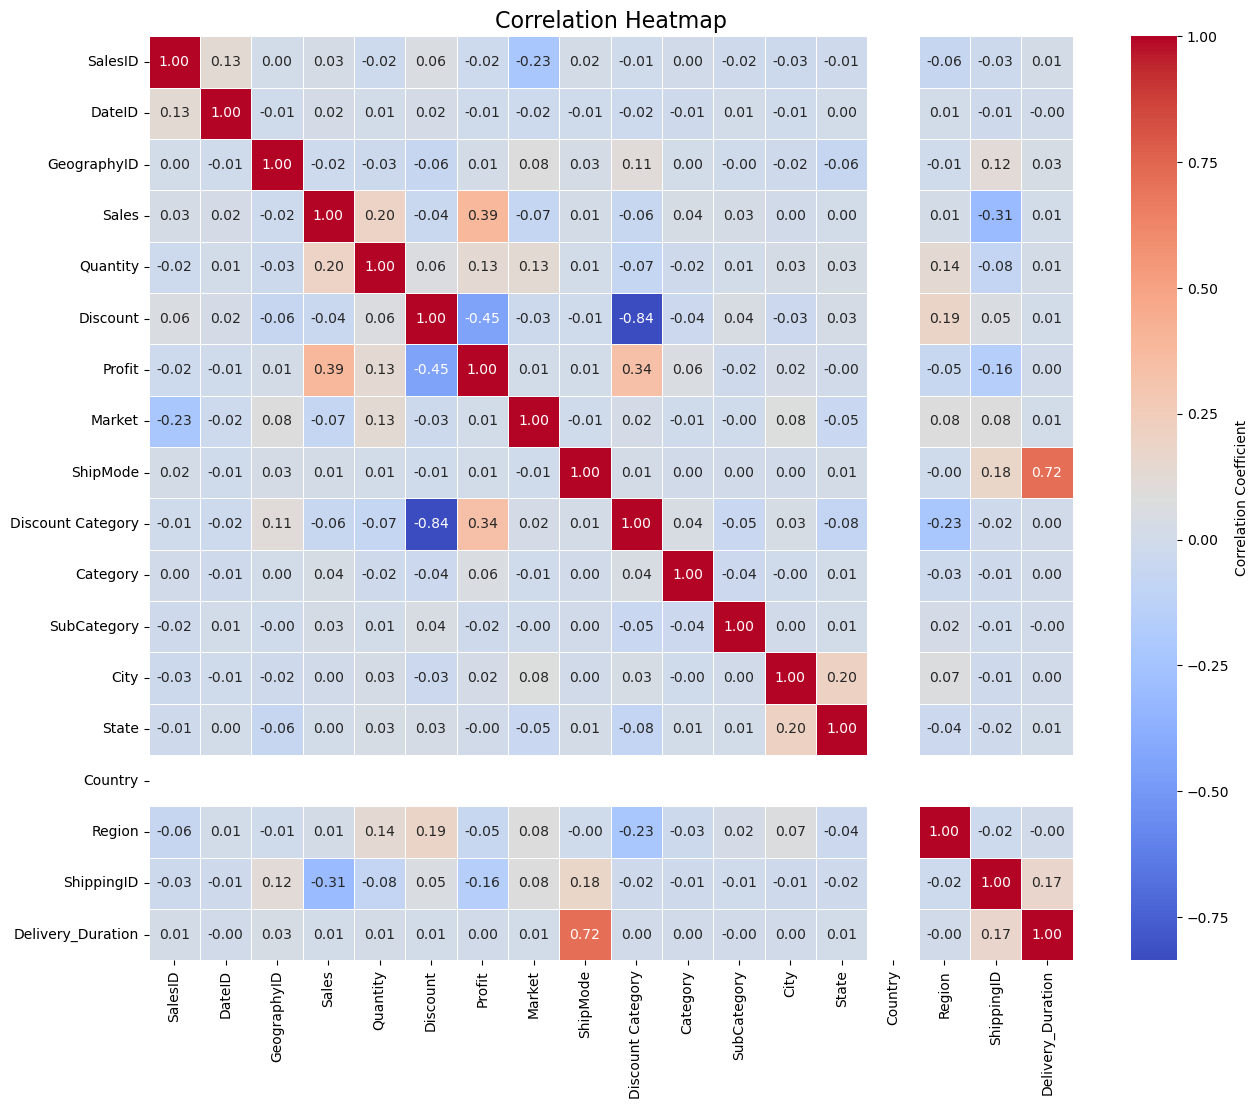

In [289]:
# Compute correlation matrix for numeric columns
corr = merged.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'}, square=True)  
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [ ]:
# Selecting features and target variable
features = ['Sales', 'Quantity', 'Discount', 'Profit', 'Category', 'SubCategory', 
            'Market',  'City', 'State', 'Region', 'Delivery_Duration']
X = merged[features]
y = merged['ShipMode']

In [252]:
# Standardizing numerical features
numeric_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])


In [206]:
# Handling imbalanced data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


c:\Users\2021\anaconda3\envs\quera\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [207]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [208]:
# Train models
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)


In [209]:
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [210]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [211]:
# Evaluate models
print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

print("Gradient Boosting Accuracy: ", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))


Random Forest Accuracy:  0.9137127371273712
Random Forest Classification Report:
                 precision    recall  f1-score   support

   First Class       0.89      0.92      0.91      4675
      Same Day       1.00      1.00      1.00      4651
  Second Class       0.89      0.75      0.81      4593
Standard Class       0.88      0.99      0.93      4531

      accuracy                           0.91     18450
     macro avg       0.91      0.91      0.91     18450
  weighted avg       0.91      0.91      0.91     18450

Gradient Boosting Accuracy:  0.8094308943089431
Gradient Boosting Classification Report:
                 precision    recall  f1-score   support

   First Class       0.67      0.88      0.76      4675
      Same Day       1.00      0.99      1.00      4651
  Second Class       0.75      0.37      0.49      4593
Standard Class       0.83      1.00      0.91      4531

      accuracy                           0.81     18450
     macro avg       0.81      0.81    

In [212]:
# Feature Importance
feature_importance_rf = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
feature_importance_gb = pd.DataFrame({'Feature': features, 'Importance': gb.feature_importances_})

print("\nRandom Forest Feature Importance:")
print(feature_importance_rf.sort_values(by='Importance', ascending=False))

print("\nGradient Boosting Feature Importance:")
print(feature_importance_gb.sort_values(by='Importance', ascending=False))


Random Forest Feature Importance:
              Feature  Importance
10  Delivery_Duration    0.589622
7              City_x    0.065306
1            Quantity    0.062956
0               Sales    0.062096
3              Profit    0.061216
8             State_x    0.051427
5         SubCategory    0.036557
9            Region_x    0.022714
2            Discount    0.018633
6            Market_x    0.017218
4            Category    0.012254

Gradient Boosting Feature Importance:
              Feature  Importance
10  Delivery_Duration    0.950234
1            Quantity    0.034902
7              City_x    0.006038
8             State_x    0.002558
4            Category    0.001731
3              Profit    0.001042
9            Region_x    0.000861
0               Sales    0.000852
5         SubCategory    0.000773
6            Market_x    0.000515
2            Discount    0.000494


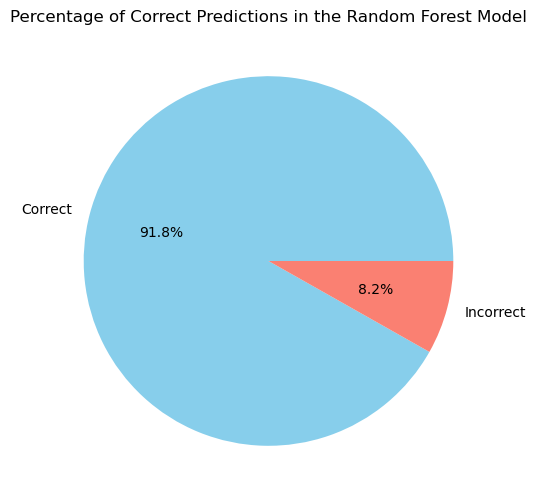

In [244]:
# Calculate the number of correct and incorrect predictions
correct = sum(y_test == y_pred_rf)
incorrect = len(y_test) - correct

# Plot a pie chart
plt.figure(figsize=(6, 6))
plt.pie([correct, incorrect], labels=["Correct", "Incorrect"], autopct="%1.1f%%", colors=["skyblue", "salmon"])
plt.title("Percentage of Correct Predictions in the Random Forest Model")
plt.show()


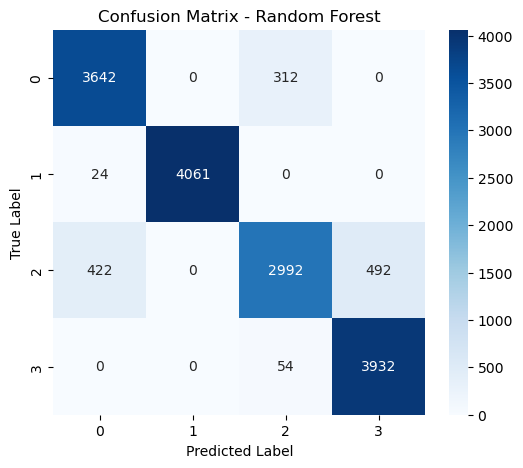

In [291]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()